# Unemployment Analysis in India

## Oasis Infobyte Data Science Internship

### Task 2 - Unemployment Analysis with Python

**Prepared by:** Bhvya Vaish


# Project Overview

Unemployment is one of the most important economic indicators of a country's development. During the COVID-19 pandemic, unemployment rates increased significantly across various regions of India due to lockdowns and economic disruptions.

This project aims to analyze unemployment trends across Indian states using Python and data analysis techniques. The dataset contains information related to unemployment rate, employment count, labour participation rate and geographical areas.

Through exploratory data analysis and data visualization, the project identifies regional unemployment patterns, urban-rural differences and the impact of COVID-19 on employment.


# Objectives

The main objectives of this project are:

* To understand unemployment trends across Indian states.
* To identify states with the highest unemployment rates.
* To analyze unemployment patterns before and during the COVID-19 period.
* To compare unemployment levels between urban and rural regions.
* To study the relationship between employment, unemployment and labour participation rates.
* To derive meaningful insights using data visualization and statistical analysis.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Oasis Internship Datasets/Unemployment in India.csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.columns


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [9]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [11]:
df = df.dropna()

In [12]:
df.shape

(740, 7)

In [13]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [14]:
df.describe()


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [17]:
df[' Date'] = pd.to_datetime(df[' Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Region                                    740 non-null    object        
 1    Date                                     740 non-null    datetime64[ns]
 2    Frequency                                740 non-null    object        
 3    Estimated Unemployment Rate (%)          740 non-null    float64       
 4    Estimated Employed                       740 non-null    float64       
 5    Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                      740 non-null    object        
 7   Date                                      740 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(3)
memory usage: 52.0+ KB


/tmp/ipykernel_2296/2213085900.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[' Date'] = pd.to_datetime(df[' Date'])


In [19]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Date'],
      dtype='object')

In [21]:
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

state_unemployment.sort_values(ascending=False).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


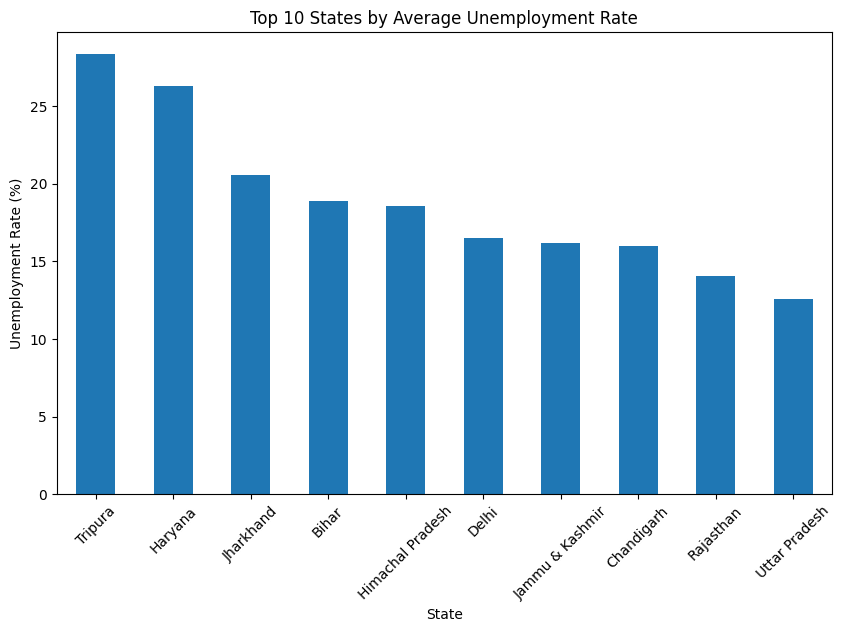

In [22]:
import matplotlib.pyplot as plt

top10 = state_unemployment.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top10.plot(kind='bar')

plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.show()

## Observation

Tripura recorded the highest average unemployment rate (28.35%) among all states in the dataset.

Haryana and Jharkhand also showed significantly high unemployment rates (above 20%).

Uttar Pradesh and Rajastahn had sugnificantly low average unemployment rates (below 15%).

The analysis indicates that unemployment was concentrated in specific regions rather than being evenly distributed across India.

In [23]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

monthly_unemployment.head()

ValueError: Grouper for 'Date' not 1-dimensional

In [24]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Date'],
      dtype='object')

In [25]:
df = df.loc[:, ~df.columns.duplicated()]

In [26]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [27]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

monthly_unemployment.head()

,Estimated Unemployment Rate (%)
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731


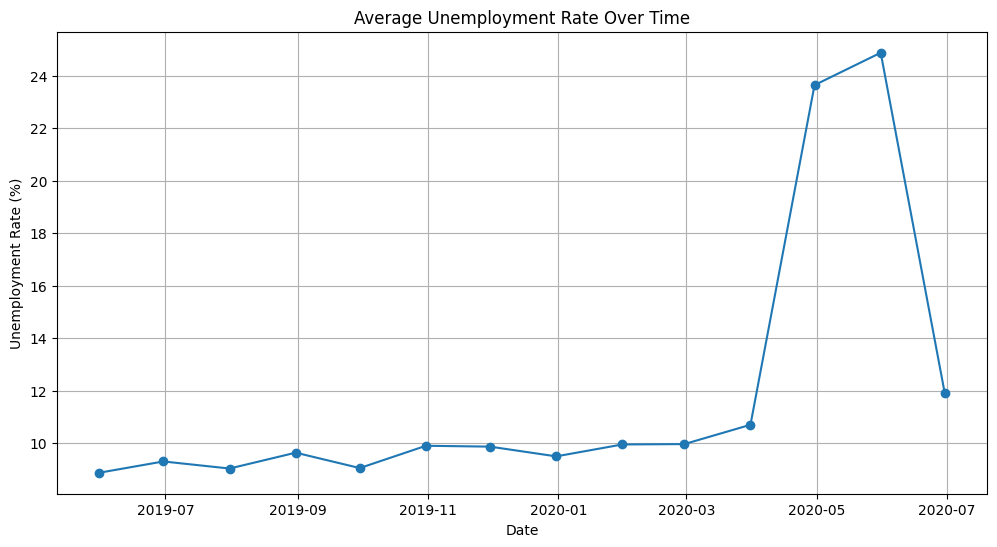

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(monthly_unemployment.index,
         monthly_unemployment.values,
         marker='o')

plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.grid(True)

plt.show()

## Observation

The unemployment rate remained relatively stable between May 2019 and March 2020, averaging around 9-10%.

A sharp increase in unemployment was observed during April-June 2020, coinciding with the COVID-19 lockdown period in India.

The unemployment rate reached its peak of approximately 24.8% in June 2020.

After June 2020, unemployment declined significantly indicating a gradual recovery in economic activities and employment opportunities.

In [29]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [31]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [33]:
area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

area_unemployment

,Estimated Unemployment Rate (%)
Area,
Rural,10.324791
Urban,13.166614


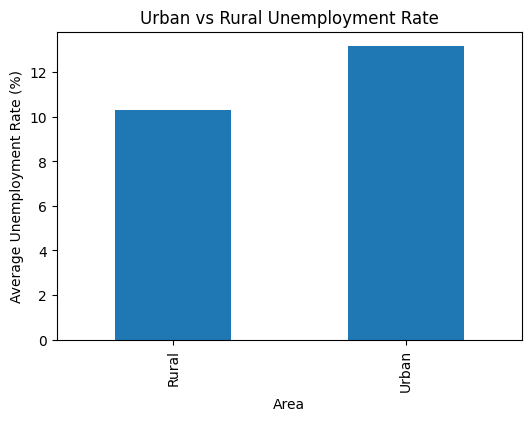

In [34]:
import matplotlib.pyplot as plt

area_unemployment.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Urban vs Rural Unemployment Rate')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

## Interpretation
Urban areas experienced higher unemployment than rural areas.
This may indicate stronger impact of lockdowns on urban industries and services.

Rural areas showed relatively lower unemployment rates, possibly due
to continued agricultural activities and rural employment schemes.italicized text

In [35]:
top_employed = df.groupby('Region')['Estimated Employed'].mean().sort_values(ascending=False).head(10)

top_employed

,Estimated Employed
Region,
Uttar Pradesh,2.809483e+07
Maharashtra,1.999020e+07
West Bengal,1.719854e+07
Bihar,1.236619e+07
Tamil Nadu,1.226955e+07
Gujarat,1.140201e+07
Madhya Pradesh,1.111548e+07
Karnataka,1.066712e+07
Rajasthan,1.004106e+07


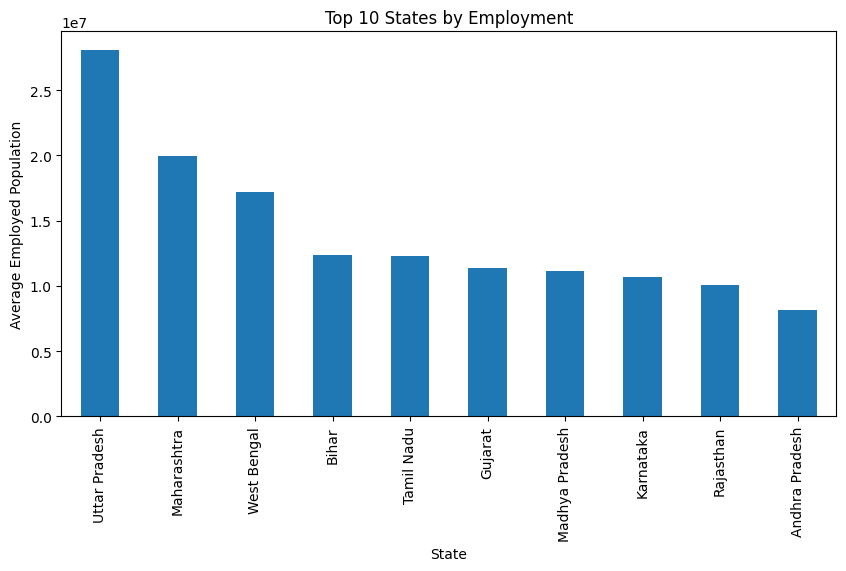

In [36]:
plt.figure(figsize=(10,5))

top_employed.plot(kind='bar')

plt.title('Top 10 States by Employment')
plt.ylabel('Average Employed Population')
plt.xlabel('State')

plt.show()

## Interpretation

Uttar Pradesh recorded the highest average employed population among
all states in the dataset.

Maharashtra and West Bengal also showed high employment levels,
reflecting their large workforce and population size.

States with larger populations generally exhibited higher employment
figures compared to smaller states.

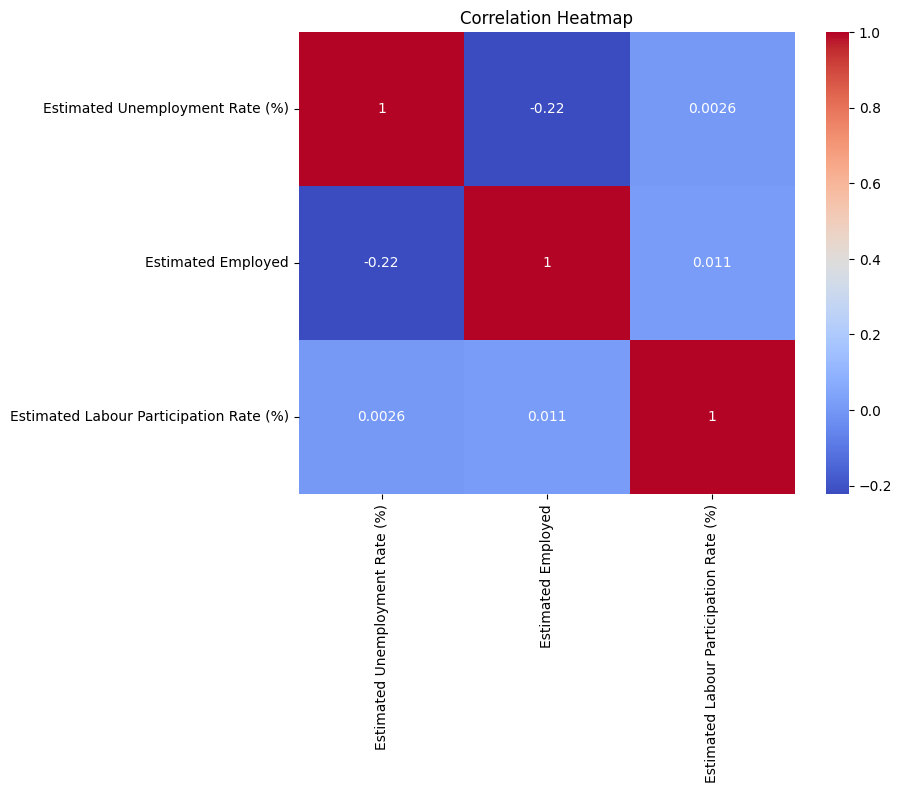

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

### Observation

The correlation heatmap indicates a weak negative relationship (-0.22) between employment and unemployment rates, suggesting that regions with higher employment levels generally tend to have lower unemployment rates.

The labour participation rate showed almost no significant correlation with either employment or unemployment. This implies that workforce participation alone does not strongly influence unemployment trends within this dataset.

Overall, the analysis suggests that unemployment in Indian states is influenced by multiple economic and regional factors beyond labour force participation.


# Conclusion

This project analyzed unemployment trends across India using Python and data visualization techniques.

Key findings from the analysis include:

- Certain states such as Tripura and Haryana experienced significantly higher unemployment rates compared to others.
- A major spike in unemployment was observed during the COVID-19 lockdown period (April-June 2020).
- Urban areas showed higher average unemployment rates than rural areas.
- States with larger employed populations were not necessarily associated with lower unemployment rates.
- Correlation analysis indicated only a weak relationship between employment and unemployment, suggesting that multiple economic and regional factors influence unemployment levels.

Overall, the analysis highlights the impact of economic disruptions and regional differences on employment opportunities across India.